# Introduction to  **Data Discretization** and **Binning**

Data Discretization (commonly referred to as **Binning** or **Quantization**) is a foundational feature engineering technique designed to convert continuous numeric features into discrete categorical variables or binary indicators. 

- Discretization is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values.

- Discretization is also called as binning , where bin is an alternative name for interval

Why use Discretization?
1. To handle Outliers
2. To Improve the value spread



Instead of passing an infinite, smooth spectrum of continuous numbers $X \in \mathbb{R}$ into a machine learning model, discretization partitions the data space into a finite, ordered set of intervals or buckets $X \in \{1, 2, ..., N\}$.

## 1. Algorithmic Characteristics of Binning

When we apply discretization to a feature, it alters how machine learning models interpret the data grid through three primary mechanisms:

**1.Non-Linear Representation:** While mathematical transformations (like Log or Box-Cox) change the *shape* of a continuous curve,discretization  destroys the curve entirely. It transforms a smooth slope into a step function, mimicking a flight of stairs.

**2.Noise and Outlier Filtering:** Small fluctuations, minor measurement errors, and extreme outliers falling within a specific bucket interval are    completely smoothed out. The model treats every value within a given bin as structurally identical, which reduces variance and over-fitting.

**3.Capturing Step-Function Thresholds:** Many real-world behaviors do not scale linearly. For example, a credit card default risk might jump drastically at specific credit score thresholds rather than rising smoothly point-by-point. Binning allows linear models to naturally capture these distinct non-linear shifts.




## 2. The Taxonomy of Data Discretization

Data Discretization is architecturally divided into three high-level paradigms based on how the boundary thresholds of the bins are calculated:

#### **i. Unsupervised Binning**

*   **Core Principle:** Bin boundaries are determined solely by analyzing the distribution, range, or clustering density of the input feature ($X$). The target column ($y$) is completely ignored.

*   **Key Algorithms:** Uniform (Equal-Width), Quantile (Equal-Frequency), and KMeans (Clustering-Based) Binning.

*   **Characteristics:** Simple to implement, works out-of-the-box in Scikit-Learn (`KBinsDiscretizer`), but risks creating boundaries that completely separate or dilute the target class signals.

#### **ii. Supervised Binning**

*   **Core Principle:** The algorithm checks both the input feature ($X$) and the target label ($y$) simultaneously. It places bin boundaries at the exact locations that maximize the predictive power or relationship with the target variable.

*   **Key Algorithms:** Decision Tree Splitting (using Entropy/Gini impurity) and Weight of Evidence (WoE) / Optimal Binning.

*   **Characteristics:** Highly powerful for predictive modeling, but introduces a risk of overfitting if the boundaries adapt too closely to noise in the training set target.

#### **iii. Custom (Domain-Driven) Binning**

*   **Core Principle:** Bin boundaries are manually hardcoded by a data scientist using expert industry knowledge, completely ignoring automated statistical distributions or target behaviors.

*   **Key Algorithms:** User-defined condition maps (e.g., using `pd.cut()` with manual edge arrays).

*   **Characteristics:** Captures strict real-world definitions flawlessly (e.g., categorizing medical blood pressure scores or standard credit scoring tier limits).


## 3. Unsupervised Binning Techniques

Unsupervised binning relies entirely on the structural characteristics of the raw feature matrix. It is implemented in Scikit-Learn using the `KBinsDiscretizer` class, configured via the `strategy` hyperparameter.



#### **i. Uniform Binning** (`strategy='uniform'`)

Uniform (Equal-Width) binning divides the entire mathematical range of a feature (from its absolute minimum to its absolute maximum value) into intervals of identical width.
e.g. For interval = 10. Each interval contains 10% of total observations. so intervals are : 0-16, 16-20, 20-22, 22-25....

*   **Mathematical Boundary Rule:** 
    $\text{Width} = \frac{\text{Max}(X) - \text{Min}(X)}{N}$

*   **Characteristics:** It functions independently of data density. If the dataset contains heavy extreme right-side outliers, the range span expands aggressively, causing the majority of normal data points to be forced into a single cramped bucket, leaving the remaining buckets completely empty.



#### **ii. Quantile Binning** (`strategy='quantile'`)

Quantile (Equal-Frequency) binning divides continuous data into intervals based on percentiles, ensuring that every resulting bucket contains roughly the exact same number of data samples.

*   **Mathematical Boundary Rule:** 
    $\text{Boundaries} = \text{Percentiles at steps of } \left(\frac{100}{N}\right)$

*   **Characteristics:** It adapts exceptionally well to skewed data by automatically widening bins in sparse regions and narrowing bins in dense regions. However, if the data features many identical repeating values (e.g., many zeros), it can force identical values into separate buckets, breaking data integrity.



#### **iii. KMeans Binning** (`strategy='kmeans'`)

KMeans (Clustering-Based) binning applies a 1-dimensional k-means clustering algorithm to partition the continuous feature values into distinct density-based groups.

*   **Mathematical Boundary Rule:** The algorithm initializes $N$ centroids along the 1D line and iteratively assigns data points to the nearest centroid. The bin walls are set precisely at the midpoint between adjacent final centroids:
    $\text{Boundary}_{i} = \frac{\text{Centroid}_{i} + \text{Centroid}_{i+1}}{2}$

*   **Characteristics:** It respects the natural spatial architecture of the feature. It naturally separates data into logical sub-populations, keeping tight data clusters grouped within the same bin while isolating sparse regions.


###  The Four Core Discretization Frameworks

Depending on the underlying data distribution and the requirements of your machine learning estimator, you can leverage four primary binning strategies:

#### 1. Binarization

*   **Mechanism:** Splits a continuous feature into exactly two distinct categories (**0** and **1**) based on a single, predefined hard mathematical threshold.
*   **Best Used For:** Creating flag or indicator features (e.g., transforming a continuous "Account Balance" into an "Is_Active" binary flag).

#### 2. Uniform (Equal-Width) Binning

*   **Mechanism:** Divides the entire span of the feature (from absolute minimum to absolute maximum) into $N$ intervals that possess the exact same mathematical range width.
*   **Best Used For:** Uniformly distributed data where the physical scale intervals carry strict real-world meaning, regardless of how many data samples fall into each bucket.

#### 3. Quantile (Equal-Frequency) Binning

*   **Mechanism:** Computes percentiles to establish bin boundaries. This ensures that every single bucket contains roughly the exact same number of data rows.
*   **Best Used For:** Heavily skewed, long-tailed, or clustered distributions where equal-width binning would leave some buckets completely empty.

#### 4. KMeans (Clustering-Based) Binning

*   **Mechanism:** Runs a 1-dimensional clustering algorithm to group continuous values based on their physical spatial proximity and density patterns along the numeric timeline.
*   **Best Used For:** Datasets that contain natural, distinct sub-populations or multi-modal clumps that you want the model to isolate automatically.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer



In [4]:
# Import the dataset and select only the relevant columns
df = pd.read_csv('../../data/titanic.csv', usecols=['Age', 'Fare', 'Survived'])
print(f"Shape of the dataset: {df.shape}")
df.head()

Shape of the dataset: (891, 3)


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.dropna(inplace=True)
df.shape

(714, 3)

In [6]:
# Split the dataset into features and target variable

X = df.iloc[:,1:]
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Without Discretization

In [7]:
def model_decision_tree(X_train, X_test, y_train, y_test):
    
    # Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=42)
    
    # Fit the model on the training data and evaluate on the test data
    clf.fit(X_train, y_train)
    
    # Make predictions on the test data
    y_pred = clf.predict(X_test)
    
    # Calculate accuracy and cross-validation scores
    accuracy = accuracy_score(y_test, y_pred)
    
    X_combined = pd.concat([X_train, X_test], axis=0)
    y_combined = pd.concat([y_train, y_test], axis=0)
    
    cross_val_scores = cross_val_score(clf, X_combined, y_combined, cv=15, scoring='accuracy')
    
    return accuracy, cross_val_scores.mean()

accuracy, cross_val_scores = model_decision_tree(X_train, X_test, y_train, y_test)

print(f"Accuracy of the Decision Tree Classifier: {accuracy:.4f}")
print(f"Mean cross-validation score: {cross_val_scores:.4f}")

Accuracy of the Decision Tree Classifier: 0.6224
Mean cross-validation score: 0.6219


## Apply Other Discretization

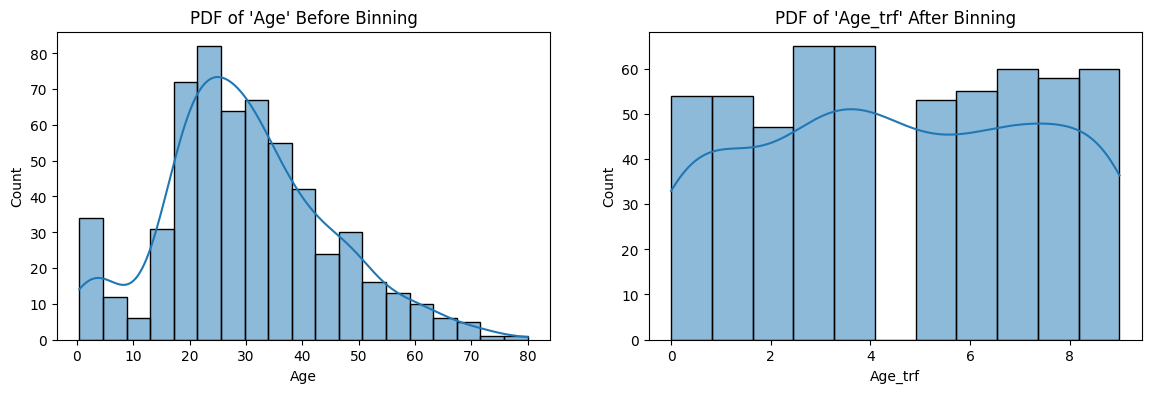

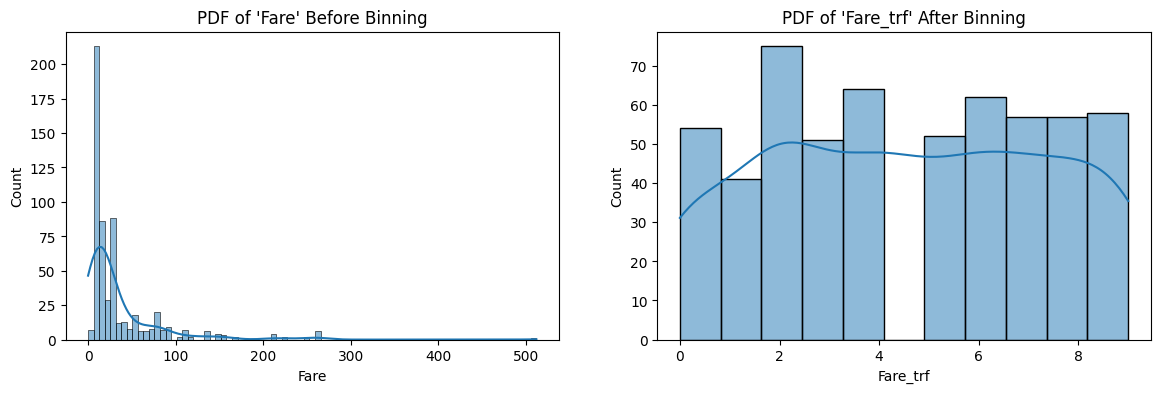

In [8]:
class apply_discretization:
    
    def __init__(self, X_train,X_test):
        self.X_train = X_train
        self.X_test = X_test
        
    def binning(self, bins=10 ,apply_strategy='uniform', bininter=False):
        
        kbin_age = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=apply_strategy)
        kbin_fare = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy=apply_strategy)
        
        trf = ColumnTransformer([
                ('age_binning', kbin_age, [0]),
                ('fare_binning', kbin_fare, [1])   
        ])
        
        X_train_binned = trf.fit_transform(self.X_train)
        X_test_binned = trf.transform(self.X_test) ## trf.named_transformers_['age_binning'].bin_edges_
        
        X_train_binned = pd.DataFrame(X_train_binned, columns=['Age_trf','Fare_trf'], index=self.X_train.index)
        X_test_binned = pd.DataFrame(X_test_binned, columns=['Age_trf','Fare_trf'], index=self.X_test.index)
        
        output = pd.DataFrame({
            'Age': self.X_train['Age'],
            'Age_trf': X_train_binned['Age_trf'],
            'Fare': self.X_train['Fare'],
            'Fare_trf': X_train_binned['Fare_trf']
        })
        
        if bininter :
            output['Age_labels'] = pd.cut(x=self.X_train['Age'], bins=trf.named_transformers_['age_binning'].bin_edges_[0].tolist())
            output['Fare_labels'] = pd.cut(x=self.X_train['Fare'], bins=trf.named_transformers_['fare_binning'].bin_edges_[0].tolist())
            
        return X_train_binned, X_test_binned, output
    
    def plot_hist(self, X_train_binned):
        for col1, col2 in zip(self.X_train.columns, X_train_binned.columns):
            plt.figure(figsize=(14, 4))
            plt.subplot(121)
            sns.histplot(data=self.X_train[col1], kde=True)
            plt.title(f"PDF of '{col1}' Before Binning")
            
            plt.subplot(122)
            sns.histplot(data=X_train_binned[col2], kde=True)
            plt.title(f"PDF of '{col2}' After Binning")


test1 = apply_discretization(X_train, X_test)
X_train_b, X_test_b, output = test1.binning(apply_strategy='quantile',bininter=True)
test1.plot_hist(X_train_b)

### 1. Uniform Binning

In [9]:
Uniform_binning = apply_discretization(X_train, X_test)
X_train_ub, X_test_ub, output_ub = Uniform_binning.binning(apply_strategy='uniform', bininter=True)
output_ub

,Age,Age_trf,Fare,Fare_trf,Age_labels,Fare_labels
328,31.0,3.0,20.5250,0.0,"(24.294, 32.252]","(0.0, 51.233]"
73,26.0,3.0,14.4542,0.0,"(24.294, 32.252]","(0.0, 51.233]"
253,30.0,3.0,16.1000,0.0,"(24.294, 32.252]","(0.0, 51.233]"
719,33.0,4.0,7.7750,0.0,"(32.252, 40.21]","(0.0, 51.233]"
666,25.0,3.0,13.0000,0.0,"(24.294, 32.252]","(0.0, 51.233]"
...,...,...,...,...,...,...
92,46.0,5.0,61.1750,1.0,"(40.21, 48.168]","(51.233, 102.466]"
134,25.0,3.0,13.0000,0.0,"(24.294, 32.252]","(0.0, 51.233]"
337,41.0,5.0,134.5000,2.0,"(40.21, 48.168]","(102.466, 153.699]"
548,33.0,4.0,20.5250,0.0,"(32.252, 40.21]","(0.0, 51.233]"


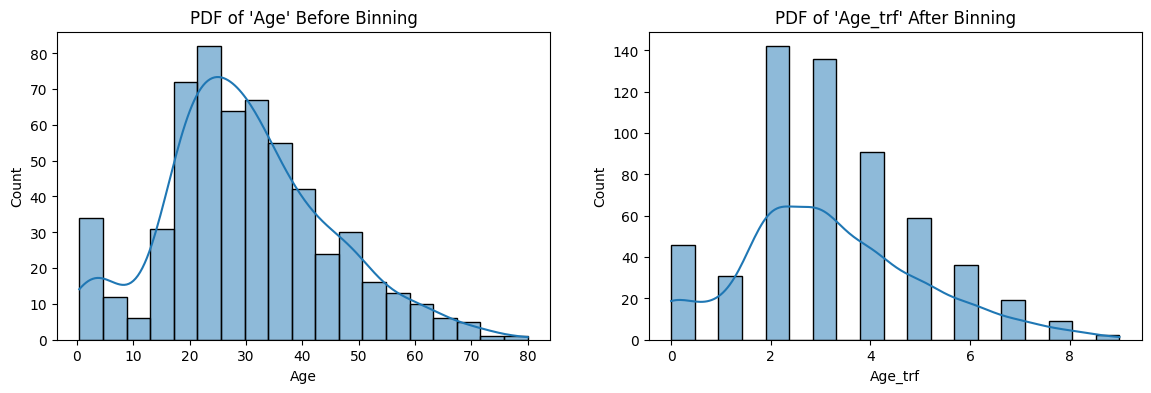

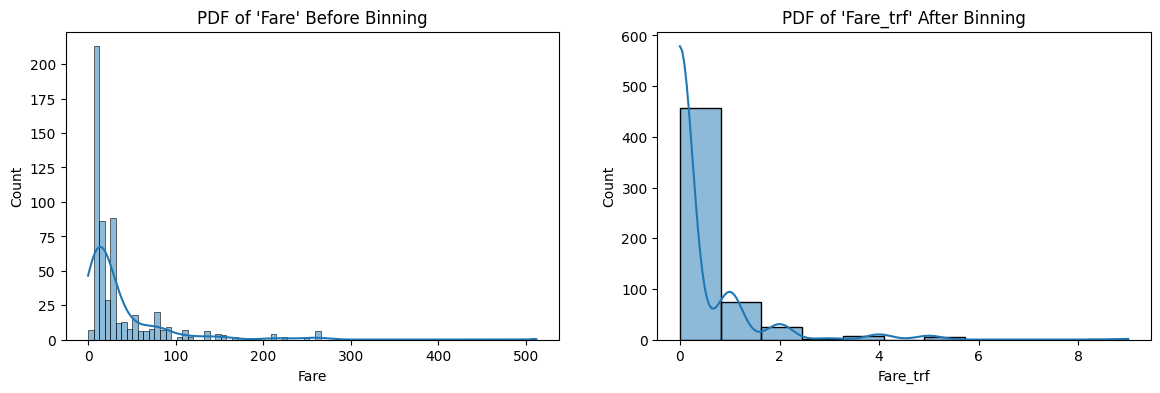

In [10]:
Uniform_binning.plot_hist(X_train_ub)

In [11]:
accuracy_ub , cross_val_score_ub = model_decision_tree(X_train_ub, X_test_ub, y_train, y_test)
print(f"Accuracy of the Decision Tree Classifier: {accuracy_ub:.4f}")
print(f"Mean cross-validation score: {cross_val_score_ub:.4f}")

Accuracy of the Decision Tree Classifier: 0.6783
Mean cross-validation score: 0.6832


### 2. Quantile Binning

In [12]:
Quantile_binning = apply_discretization(X_train, X_test)
X_train_qb, X_test_qb, output_qb = Quantile_binning.binning(apply_strategy='quantile', bininter=True)
output_qb

,Age,Age_trf,Fare,Fare_trf,Age_labels,Fare_labels
328,31.0,5.0,20.5250,5.0,"(28.5, 32.0]","(15.75, 26.0]"
73,26.0,4.0,14.4542,4.0,"(25.0, 28.5]","(13.0, 15.75]"
253,30.0,5.0,16.1000,5.0,"(28.5, 32.0]","(15.75, 26.0]"
719,33.0,6.0,7.7750,1.0,"(32.0, 36.0]","(7.75, 7.896]"
666,25.0,4.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"
...,...,...,...,...,...,...
92,46.0,8.0,61.1750,8.0,"(42.0, 50.0]","(51.479, 82.171]"
134,25.0,4.0,13.0000,4.0,"(22.0, 25.0]","(9.225, 13.0]"
337,41.0,7.0,134.5000,9.0,"(36.0, 42.0]","(82.171, 512.329]"
548,33.0,6.0,20.5250,5.0,"(32.0, 36.0]","(15.75, 26.0]"


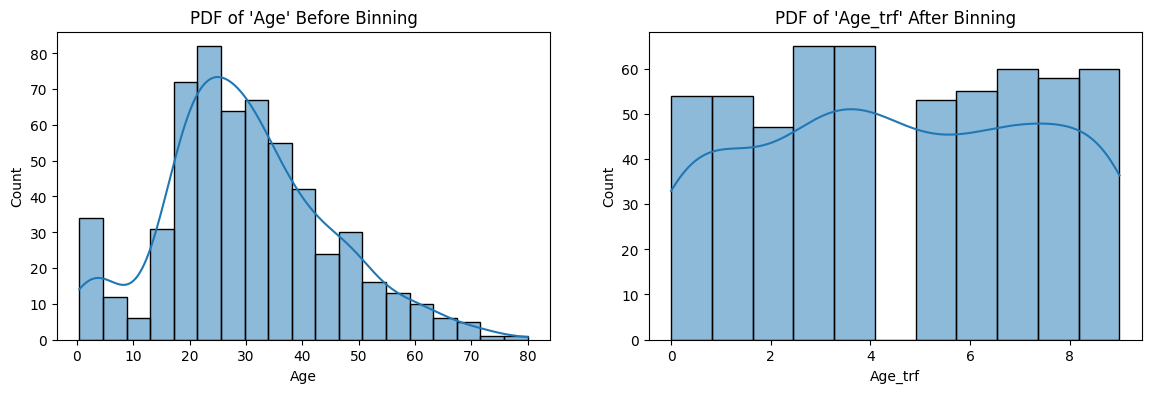

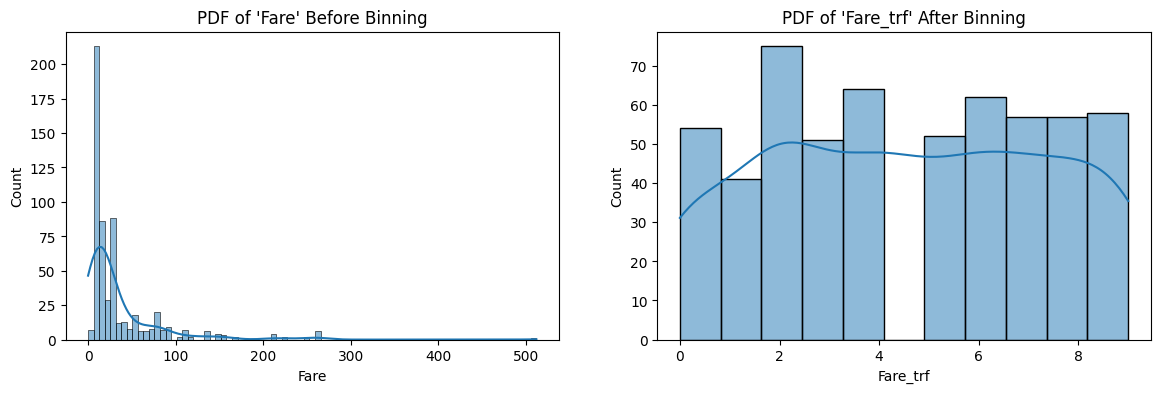

In [13]:
Quantile_binning.plot_hist(X_train_qb)

In [14]:
accuracy_qb , cross_val_score_qb = model_decision_tree(X_train_qb, X_test_qb, y_train, y_test)
print(f"Accuracy of the Decision Tree Classifier: {accuracy_qb:.4f}")
print(f"Mean cross-validation score: {cross_val_score_qb:.4f}")

Accuracy of the Decision Tree Classifier: 0.6224
Mean cross-validation score: 0.6580


### 3. KMeans

In [15]:
KMeans_binning = apply_discretization(X_train, X_test)
X_train_kmb, X_test_kmb, output_kmb = Quantile_binning.binning(apply_strategy='kmeans', bininter=True)
output_kmb

,Age,Age_trf,Fare,Fare_trf,Age_labels,Fare_labels
328,31.0,3.0,20.5250,1.0,"(24.835, 32.42]","(18.311, 38.121]"
73,26.0,3.0,14.4542,0.0,"(24.835, 32.42]","(0.0, 18.311]"
253,30.0,3.0,16.1000,0.0,"(24.835, 32.42]","(0.0, 18.311]"
719,33.0,4.0,7.7750,0.0,"(32.42, 40.345]","(0.0, 18.311]"
666,25.0,3.0,13.0000,0.0,"(24.835, 32.42]","(0.0, 18.311]"
...,...,...,...,...,...,...
92,46.0,5.0,61.1750,2.0,"(40.345, 48.112]","(38.121, 62.68]"
134,25.0,3.0,13.0000,0.0,"(24.835, 32.42]","(0.0, 18.311]"
337,41.0,5.0,134.5000,5.0,"(40.345, 48.112]","(107.124, 138.325]"
548,33.0,4.0,20.5250,1.0,"(32.42, 40.345]","(18.311, 38.121]"


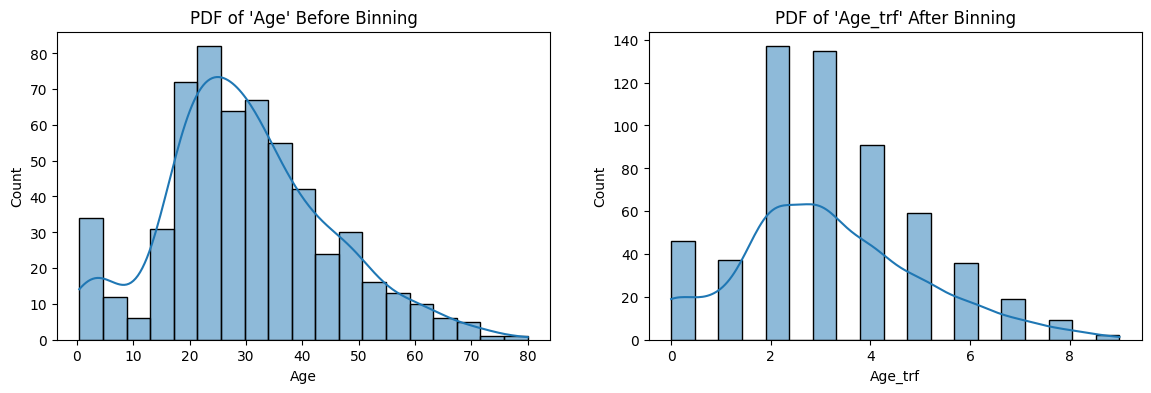

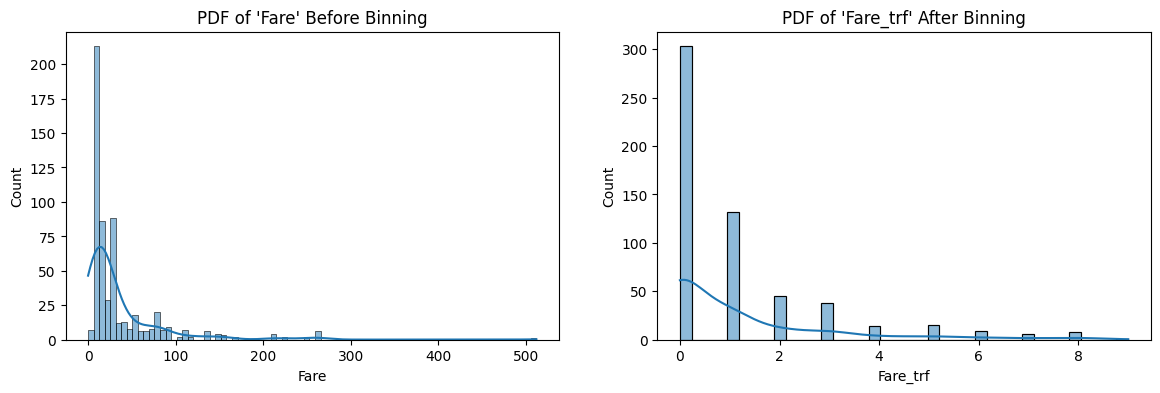

In [16]:
KMeans_binning.plot_hist(X_train_kmb)

In [17]:
accuracy_kmb , cross_val_score_kmb = model_decision_tree(X_train_kmb, X_test_kmb, y_train, y_test)
print(f"Accuracy of the Decision Tree Classifier:{accuracy_kmb:.4f}") 
print(f"Mean cross-validation score: {cross_val_score_kmb:.4f}")

Accuracy of the Decision Tree Classifier:0.6154
Mean cross-validation score: 0.6566


# Binarization 

In [20]:
# Importing Dataset
df1 = pd.read_csv("../../data/titanic.csv")[['Age', 'Fare', 'SibSp', 'Parch', 'Survived']]
df1.dropna(inplace=True)
df1.head()

,Age,Fare,SibSp,Parch,Survived
0,22.0,7.2500,1,0,0
1,38.0,71.2833,1,0,1
2,26.0,7.9250,0,0,1
3,35.0,53.1000,1,0,1
4,35.0,8.0500,0,0,0


In [21]:
df1['Family'] = df1['SibSp'] + df1['Parch']
df1.head()

,Age,Fare,SibSp,Parch,Survived,Family
0,22.0,7.2500,1,0,0,1
1,38.0,71.2833,1,0,1,1
2,26.0,7.9250,0,0,1,0
3,35.0,53.1000,1,0,1,1
4,35.0,8.0500,0,0,0,0


In [22]:
df1.drop(columns=['SibSp', 'Parch'],axis=0, inplace=True)
df1.head()

,Age,Fare,Survived,Family
0,22.0,7.2500,0,1
1,38.0,71.2833,1,1
2,26.0,7.9250,1,0
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [23]:
X = df1.drop(columns=['Survived'])
y = df1['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 571
Test set size: 143


### Without Binarization

In [24]:
accuracy, cross_val = model_decision_tree(X_train, X_test, y_train, y_test)
print(f"Accuracy on training set: {accuracy:.4f}")
print(f"Cross-validation accuracy: {cross_val:.4f}")

Accuracy on training set: 0.6713
Cross-validation accuracy: 0.6167


### With Binarization

In [25]:
from sklearn.preprocessing import Binarizer

trf_binarizer = ColumnTransformer([
    ('binarize', Binarizer(copy=False), ['Family'])
], remainder='passthrough')

X_train_trf = trf_binarizer.fit_transform(X_train)
X_test_trf = trf_binarizer.fit_transform(X_test)

X_train_trf = pd.DataFrame(X_train_trf, columns=['Family', 'Age', 'Fare']) #trf_binarizer.get_feature_names_out()
X_test_trf = pd.DataFrame(X_test_trf, columns=['Family', 'Age', 'Fare'])

accuracy_binarized, cross_val_binarized = model_decision_tree(X_train_trf, X_test_trf, y_train, y_test)
print(f"Accuracy on training set: {accuracy_binarized:.4f}")
print(f"Cross-validation accuracy: {cross_val_binarized:.4f}")

Accuracy on training set: 0.6713
Cross-validation accuracy: 0.6138
